# 12. K-Pop 아이돌 데이터 분석과 시각화

K-Pop 아이돌 1,700여 명의 인적사항(키·몸무게·데뷔·소속사·출생지 등)을 분석하고 시각화합니다.

**데이터 출처 (Kaggle)**
- 1700+ K-Pop Idols Dataset: https://www.kaggle.com/datasets/nicolsalayoarias/all-kpop-idols
- 파일: `data/kpopidolsv3.csv` (1,778명 / 16개 컬럼)

**분석 목차**
1. 데이터 로드 + 결측치 확인
2. 데뷔 나이 계산 → 히스토그램
3. 키 vs 몸무게 산점도 (성별 구분)
4. 소속사·출생지 Top 10 막대그래프
5. 연도별 데뷔 인원 추세 + 성별 비교

## 1. 데이터 로드 + 결측치 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: 맑은 고딕) + 마이너스 기호 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 데이터 출처: https://www.kaggle.com/datasets/nicolsalayoarias/all-kpop-idols
DATA_PATH = "data/kpopidolsv3.csv"

# CSV 로드 (파일 앞에 BOM 이 있어 encoding='utf-8-sig' 로 읽는다)
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("행 x 열:", df.shape)
df.head()

행 x 열: (1778, 16)


,Stage Name,Full Name,Korean Name,K Stage Name,Date of Birth,Group,Debut,Company,Country,Second Country,Height,Weight,Birthplace,Other Group,Former Group,Gender
0,2Soul,Kim Younghoon,김영훈,이솔,10/09/1997,7 O'clock,26/08/2014,Jungle,South Korea,NaN,172.0,55.0,NaN,NaN,NaN,M
1,A.M,Seong Hyunwoo,성현우,에이엠,31/12/1996,Limitless,9/07/2019,ONO,South Korea,NaN,181.0,62.0,NaN,NaN,NaN,M
2,Ace,Jang Wooyoung,장우영,에이스,28/08/1992,VAV,31/10/2015,A team,South Korea,NaN,177.0,63.0,NaN,NaN,NaN,M
3,Aeji,Kwon Aeji,권애지,애지,25/10/1999,Hash Tag,11/10/2017,LUK,South Korea,NaN,163.0,NaN,Daegu,NaN,NaN,F
4,AhIn,Lee Ahin,이아인,아인,27/09/1999,MOMOLAND,9/11/2016,Double Kick,South Korea,NaN,160.0,44.0,Wonju,NaN,NaN,F


In [2]:
# 컬럼명에 공백이 있어 다루기 쉽도록 소문자 + 언더스코어로 정리
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(list(df.columns))

# 각 컬럼의 자료형과 결측치 개수 확인
df.info()

['stage_name', 'full_name', 'korean_name', 'k_stage_name', 'date_of_birth', 'group', 'debut', 'company', 'country', 'second_country', 'height', 'weight', 'birthplace', 'other_group', 'former_group', 'gender']
<class 'pandas.DataFrame'>
RangeIndex: 1778 entries, 0 to 1777
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   stage_name      1778 non-null   str    
 1   full_name       1769 non-null   str    
 2   korean_name     1768 non-null   str    
 3   k_stage_name    1777 non-null   str    
 4   date_of_birth   1776 non-null   str    
 5   group           1632 non-null   str    
 6   debut           1632 non-null   str    
 7   company         1632 non-null   str    
 8   country         1778 non-null   str    
 9   second_country  62 non-null     str    
 10  height          836 non-null    float64
 11  weight          566 non-null    float64
 12  birthplace      834 non-null    str    
 13  other_group    

In [3]:
# 컬럼별 결측치 비율(%)을 큰 순으로 확인
missing = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
print("결측치 비율(%)")
print(missing[missing > 0])

결측치 비율(%)
second_country    96.5
other_group       92.1
former_group      85.2
weight            68.2
birthplace        53.1
height            53.0
debut              8.2
company            8.2
group              8.2
korean_name        0.6
full_name          0.5
k_stage_name       0.1
date_of_birth      0.1
dtype: float64


In [4]:
# 날짜 컬럼을 날짜형으로 변환
# 원본 형식은 '10/09/1997' 처럼 일/월/년(dd/mm/yyyy) 이므로 dayfirst=True 지정
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], dayfirst=True, errors="coerce")
df["debut"] = pd.to_datetime(df["debut"], dayfirst=True, errors="coerce")

# 키/몸무게를 숫자형으로 변환 (변환 불가한 값은 NaN 처리)
df["height"] = pd.to_numeric(df["height"], errors="coerce")
df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

df[["stage_name", "date_of_birth", "debut", "height", "weight", "gender"]].head()

,stage_name,date_of_birth,debut,height,weight,gender
0,2Soul,1997-09-10,2014-08-26,172.0,55.0,M
1,A.M,1996-12-31,2019-07-09,181.0,62.0,M
2,Ace,1992-08-28,2015-10-31,177.0,63.0,M
3,Aeji,1999-10-25,2017-10-11,163.0,NaN,F
4,AhIn,1999-09-27,2016-11-09,160.0,44.0,F


## 2. 데뷔 나이 계산 → 히스토그램

데뷔일과 생일의 차이를 이용해 '데뷔 당시 만 나이'를 계산합니다.

In [5]:
# 데뷔 나이 = (데뷔일 - 생일) 의 일수를 365.25 로 나눠 연 단위로 환산
df["debut_age"] = (df["debut"] - df["date_of_birth"]).dt.days / 365.25

# 비정상 값(음수이거나 비현실적으로 큰 값) 제거: 10세~40세만 유효로 간주
valid_age = df["debut_age"].between(10, 40)
print(f"유효한 데뷔 나이 데이터: {valid_age.sum()}명")
print(f"평균 데뷔 나이: {df.loc[valid_age, 'debut_age'].mean():.1f}세")
print(f"최연소: {df.loc[valid_age, 'debut_age'].min():.1f}세 / 최고령: {df.loc[valid_age, 'debut_age'].max():.1f}세")

유효한 데뷔 나이 데이터: 1599명
평균 데뷔 나이: 19.6세
최연소: 10.3세 / 최고령: 33.2세


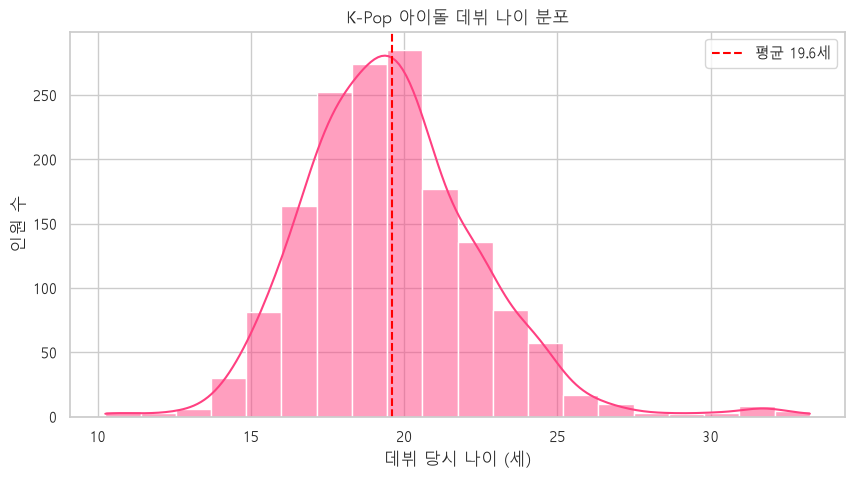

In [6]:
# [그래프 1] 데뷔 나이 분포 히스토그램
fig, ax = plt.subplots(figsize=(10, 5))

# bins=20: 막대 20개 구간 / kde=True: 분포 곡선 함께 표시
sns.histplot(df.loc[valid_age, "debut_age"], bins=20, kde=True, color="#FF4081", ax=ax)

# 평균선 표시 (빨간 점선)
mean_age = df.loc[valid_age, "debut_age"].mean()
ax.axvline(mean_age, color="red", linestyle="--", label=f"평균 {mean_age:.1f}세")

ax.set_title("K-Pop 아이돌 데뷔 나이 분포")
ax.set_xlabel("데뷔 당시 나이 (세)")
ax.set_ylabel("인원 수")
ax.legend()
plt.show()

### 💡 인사이트 2: 데뷔 나이 분포

- 평균 **19.6세**, 중앙값 **19.4세**로 평균과 중앙값이 거의 같아 **좌우 대칭에 가까운 분포**입니다.
- 표준편차가 **2.9세**로 작아, 대부분의 아이돌이 **좁은 나이대에 집중**되어 데뷔합니다.
  - **15~19세: 40.6%**, **20세 이상: 40.7%** → 10대 후반과 20대 초반이 양대 축
- **만 16세 미만 조기 데뷔도 7.8%** 존재합니다.

> 요약: 대부분 **10대 후반~20대 초반**에 데뷔하며, 그 나이대를 크게 벗어나는 경우는 드뭅니다.

## 3. 키 vs 몸무게 산점도 (성별 구분)

키와 몸무게의 관계를 성별로 색을 나눠 살펴봅니다.

키·몸무게 모두 있는 인원: 556명


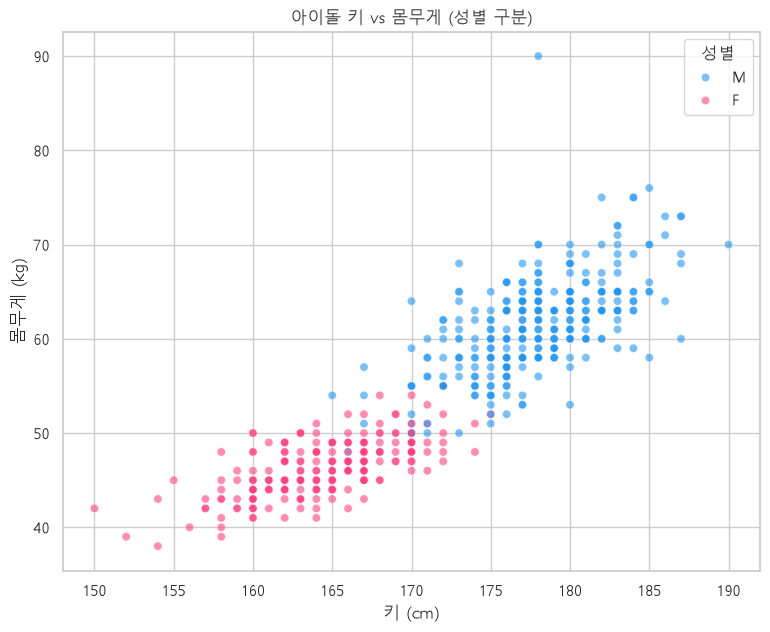

        height  weight
gender                
F        164.4    46.3
M        177.8    61.4


In [7]:
# 키/몸무게가 모두 있는 행만 사용
hw = df.dropna(subset=["height", "weight"]).copy()
print(f"키·몸무게 모두 있는 인원: {len(hw)}명")

# [그래프 2] 키 vs 몸무게 산점도
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=hw, x="height", y="weight", hue="gender",
    palette={"M": "#2196F3", "F": "#FF4081"}, alpha=0.6, ax=ax
)
ax.set_title("아이돌 키 vs 몸무게 (성별 구분)")
ax.set_xlabel("키 (cm)")
ax.set_ylabel("몸무게 (kg)")
ax.legend(title="성별")
plt.show()

# 성별 평균 키/몸무게 요약
print(hw.groupby("gender")[["height", "weight"]].mean().round(1))

### 💡 인사이트 3: 키 vs 몸무게

- 키와 몸무게는 **상관계수 0.89로 강한 양의 상관**을 보입니다. 키가 클수록 몸무게도 함께 증가하는 자연스러운 경향입니다.
- 산점도가 **성별로 두 개의 군집**으로 뚜렷이 나뉩니다.
  - 여성: 평균 **164.4cm / 46.3kg**
  - 남성: 평균 **177.8cm / 61.4kg**
- 남녀 평균 키 차이는 약 13cm, 몸무게 차이는 약 15kg입니다.

> ⚠️ **해석 주의**: 몸무게 결측이 많아 이 분석은 키·몸무게가 **모두 기록된 556명**만을 대상으로 합니다. 또한 이 수치는 일반 인구가 아닌 **아이돌 집단의 특성**(상대적으로 마른 체형)을 반영합니다.

## 4. 소속사·출생지 Top 10 막대그래프

C:\Users\User.DESKTOP-G5S2APU\AppData\Local\Temp\ipykernel_1596\2284613294.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_company.values, y=top_company.index, ax=axes[0], palette="Blues_r")
C:\Users\User.DESKTOP-G5S2APU\AppData\Local\Temp\ipykernel_1596\2284613294.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_birthplace.values, y=top_birthplace.index, ax=axes[1], palette="Greens_r")


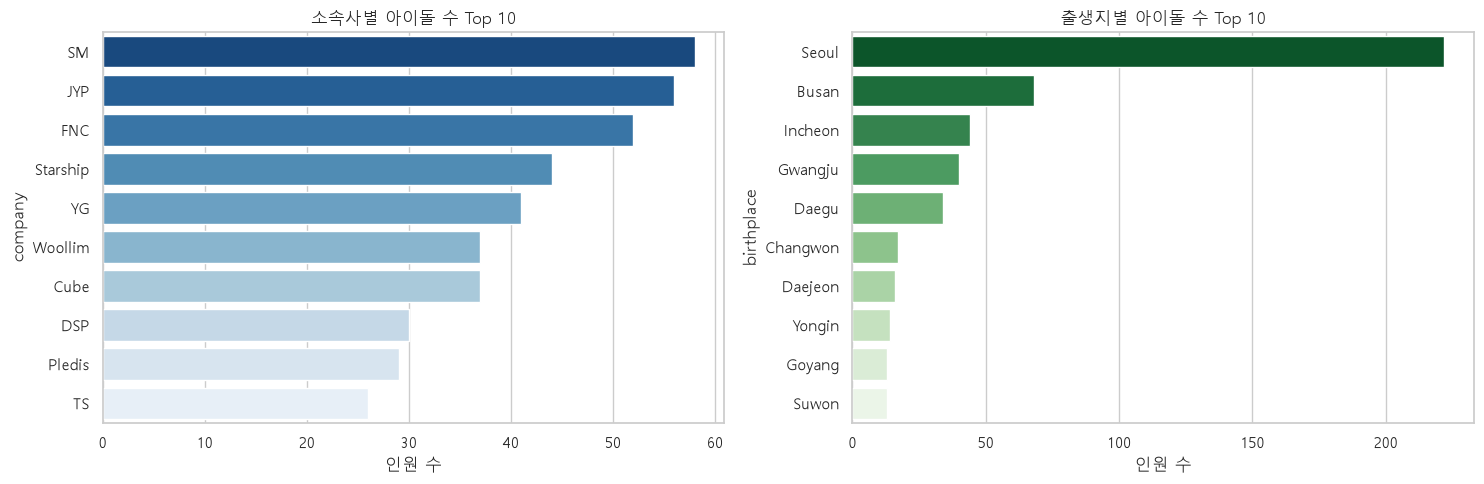

In [8]:
# 소속사별 아이돌 수 Top 10
top_company = df["company"].value_counts().head(10)

# 출생지별 아이돌 수 Top 10 (결측 제외)
top_birthplace = df["birthplace"].value_counts().head(10)

# [그래프 3] 두 개의 막대그래프를 좌우로 나란히 배치
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=top_company.values, y=top_company.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("소속사별 아이돌 수 Top 10")
axes[0].set_xlabel("인원 수")

sns.barplot(x=top_birthplace.values, y=top_birthplace.index, ax=axes[1], palette="Greens_r")
axes[1].set_title("출생지별 아이돌 수 Top 10")
axes[1].set_xlabel("인원 수")

plt.tight_layout()  # 그래프 간 간격 자동 조정
plt.show()

### 💡 인사이트 4: 소속사·출생지 분포

- 소속사는 **SM(58) · JYP(56) · FNC(52) · Starship(44) · YG(41)** 순으로, 이른바 대형 기획사에 인원이 몰려 있습니다.
- 다만 상위 10개 소속사를 합쳐도 전체(1,778명)의 일부에 불과합니다. → **소수의 대형 기획사 + 다수의 중소 기획사**로 이루어진 **롱테일(long-tail) 구조**입니다.
- 출생지는 **서울(222명)이 압도적 1위**이고, 부산(68)·인천(44)·광주(40)·대구(34) 등 대도시가 뒤를 잇습니다. → 수도권·대도시 집중 경향.

> ⚠️ **해석 주의**: `birthplace` 컬럼은 **결측이 53.1%**로 절반이 넘습니다. 위 순위는 '출생지가 기록된 인원' 안에서의 비교이므로, 전체 모집단으로 일반화할 때는 주의가 필요합니다.

## 5. 연도별 데뷔 인원 추세 + 성별 비교

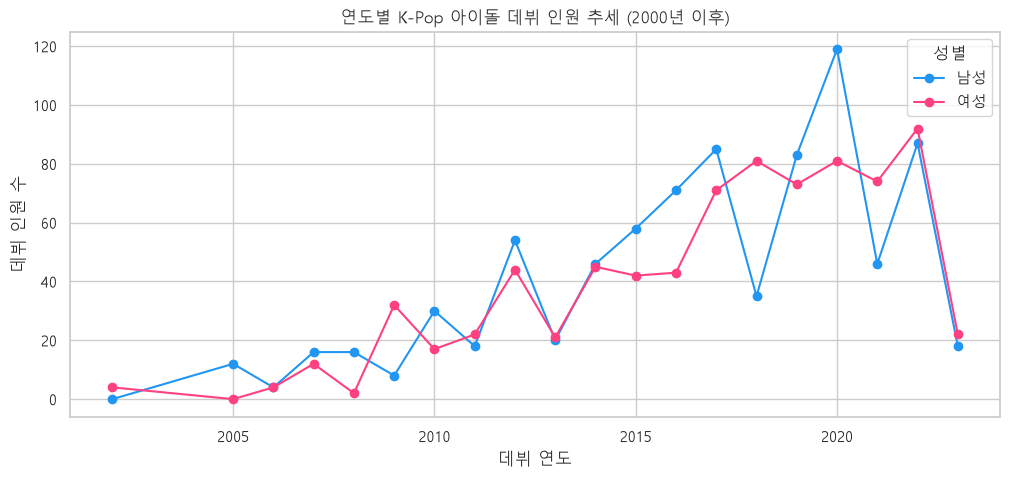

In [9]:
# 데뷔 연도 컬럼 추가
df["debut_year"] = df["debut"].dt.year

# 연도 x 성별로 데뷔 인원 집계 (피벗 테이블)
# 최근 흐름을 보기 위해 2000년 이후만 사용
yearly_gender = (
    df[df["debut_year"] >= 2000]
    .pivot_table(index="debut_year", columns="gender",
                 values="stage_name", aggfunc="count", fill_value=0)
)

# [그래프 4] 연도별 데뷔 인원 추세 (성별 선그래프)
fig, ax = plt.subplots(figsize=(12, 5))
if "M" in yearly_gender:
    ax.plot(yearly_gender.index, yearly_gender["M"], marker="o", color="#2196F3", label="남성")
if "F" in yearly_gender:
    ax.plot(yearly_gender.index, yearly_gender["F"], marker="o", color="#FF4081", label="여성")

ax.set_title("연도별 K-Pop 아이돌 데뷔 인원 추세 (2000년 이후)")
ax.set_xlabel("데뷔 연도")
ax.set_ylabel("데뷔 인원 수")
ax.legend(title="성별")
plt.show()

In [10]:
# 참고: 전체 성별 비율도 함께 확인
gender_ratio = df["gender"].value_counts()
print("성별 인원\n", gender_ratio)
print(f"\n여성 비율: {gender_ratio.get('F', 0) / gender_ratio.sum() * 100:.1f}%")

성별 인원
 gender
M    889
F    889
Name: count, dtype: int64

여성 비율: 50.0%


### 💡 인사이트 5: 연도별 데뷔 추세

- **2010년대에 데뷔 규모가 폭발적으로 성장**했습니다. 연평균 데뷔 인원이 2000년대 약 **18명** → 2010년대 약 **96명**으로 **5배 이상** 증가했습니다.
- **2020년이 200명으로 역대 최다** 데뷔를 기록했습니다.
- 2023년이 40명으로 급감한 것은 인기 하락이 아니라 **데이터 수집 시점이 2023년 중간**이라 그 해가 아직 집계 중(우측 절단, right-censored)이기 때문으로 해석해야 합니다.
- 전체 성비는 **남녀 각 889명으로 완전히 균형**이지만, 연도별로는 남성이 많은 해(2020)와 여성이 많은 해(2018·2022)가 번갈아 나타납니다.

> ⚠️ **해석 주의**: 마지막 연도의 급감은 추세가 아니라 데이터 완결성 문제일 수 있으니, 추세를 논할 땐 마지막 연도를 제외하는 것이 안전합니다.

## 6. DataFrame 직접 조회 (EDA)

그래프 대신 **DataFrame을 직접 정렬·필터링**해서 "누가 가장 ~한가?" 같은 구체적인 질문에 답합니다.
`sort_values`, `nlargest`/`nsmallest`, `idxmin`/`idxmax`, `groupby` 를 활용합니다.

- 질문 1: 가장 나이가 많은 / 어린 아이돌은?
- 질문 2: 가장 어린 / 늦은 나이에 데뷔한 아이돌은?
- 질문 3: 키가 가장 큰 / 작은 아이돌은?
- 질문 4: 멤버가 많은 그룹, 소속사별 평균 데뷔 나이는?
- 질문 5: 한국 외 국적 아이돌은 얼마나 되나?

> ⚠️ 이 셀들은 앞의 전처리(날짜 변환, `debut_age` 생성)가 끝난 상태를 전제로 하므로 노트북을 **위에서부터 순서대로** 실행하세요.

In [11]:
# [질문 1] 가장 나이가 많은 / 가장 어린 아이돌은?

# 현재 나이 계산 (오늘 날짜 기준)
today = pd.Timestamp.today().normalize()
df["age"] = (today - df["date_of_birth"]).dt.days / 365.25

# 생일이 가장 이른 사람 = 가장 나이 많은 아이돌 (idxmin: 최솟값의 인덱스)
oldest = df.loc[df["date_of_birth"].idxmin()]
print("가장 나이 많은 아이돌")
print(f"  {oldest['stage_name']} ({oldest['full_name']}) / 그룹: {oldest['group']} "
      f"/ 생일: {oldest['date_of_birth'].date()} / 현재 약 {oldest['age']:.0f}세")

# 생일이 가장 늦은 사람 = 가장 어린 아이돌
youngest = df.loc[df["date_of_birth"].idxmax()]
print("가장 어린 아이돌")
print(f"  {youngest['stage_name']} ({youngest['full_name']}) / 그룹: {youngest['group']} "
      f"/ 생일: {youngest['date_of_birth'].date()} / 현재 약 {youngest['age']:.0f}세")

# 나이 많은 순 상위 5명을 표로 확인
print("\n나이 많은 순 Top 5")
df.sort_values("date_of_birth")[["stage_name", "group", "date_of_birth", "age"]].head().round(1)

가장 나이 많은 아이돌
  PSY (Park Jaesang) / 그룹: nan / 생일: 1977-12-31 / 현재 약 49세
가장 어린 아이돌
  Chiquita (Riracha Phondechaphiphat) / 그룹: BABYMONSTER / 생일: 2009-02-17 / 현재 약 17세

나이 많은 순 Top 5


C:\Users\User.DESKTOP-G5S2APU\AppData\Local\Temp\ipykernel_1596\3356277845.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df.sort_values("date_of_birth")[["stage_name", "group", "date_of_birth", "age"]].head().round(1)


,stage_name,group,date_of_birth,age
1138,PSY,NaN,1977-12-31,48.6
292,Eric,Shinhwa,1979-02-16,47.5
1050,Minwoo,Shinhwa,1979-07-28,47.0
261,Dongwan,Shinhwa,1979-11-21,46.7
1304,Shin Hyesung,Shinhwa,1979-11-27,46.7


In [12]:
# [질문 2] 가장 어린 나이에 / 가장 늦은 나이에 데뷔한 아이돌은?

# 데뷔 나이가 유효한(10~40세) 사람만 대상
valid = df["debut_age"].between(10, 40)

print("가장 어린 나이에 데뷔한 아이돌 Top 5")
youngest_debut = df.loc[valid].nsmallest(5, "debut_age")[["stage_name", "group", "debut_age", "company"]]
print(youngest_debut.round(1).to_string(index=False))

print("\n가장 늦은 나이에 데뷔한 아이돌 Top 5")
oldest_debut = df.loc[valid].nlargest(5, "debut_age")[["stage_name", "group", "debut_age", "company"]]
oldest_debut.round(1)

가장 어린 나이에 데뷔한 아이돌 Top 5
stage_name     group  debut_age  company
    Wonjin GIDONGDAE       10.3  Simtong
     Jiwoo      KARD       10.5      DSP
     Somin      KARD       10.6      DSP
       Jia mimiimiii       11.3    Midas
       Jun    U-KISS       11.6 NH Media

가장 늦은 나이에 데뷔한 아이돌 Top 5


,stage_name,group,debut_age,company
82,Boa,KEEMBO,33.2,ARA-LINE
1397,Suhyeon,S#aFLA,33.2,Winnerzone
1473,Taeyeon,SNSD,32.4,Good Luck
1433,Sunny,SNSD,32.2,Good Luck
1489,Tiffany,SNSD,32.0,Good Luck


In [13]:
# [질문 3] 키가 가장 큰 / 가장 작은 아이돌은?

# nlargest / nsmallest 로 상위·하위 N개를 바로 추출
print("키가 가장 큰 아이돌 Top 5")
print(df.nlargest(5, "height")[["stage_name", "group", "height", "gender"]].to_string(index=False))

print("\n키가 가장 작은 아이돌 Top 5")
df.nsmallest(5, "height")[["stage_name", "group", "height", "gender"]]

키가 가장 큰 아이돌 Top 5
stage_name group  height gender
    Seoham   KNK   190.0      M
   Hyunsuk   CIX   188.0      M
      Kris   NaN   187.0      M
  Kyungmin 8TURN   187.0      M
       Lou   VAV   187.0      M

키가 가장 작은 아이돌 Top 5


,stage_name,group,height,gender
1048,Mint,Tiny-G,150.0,F
240,Dohee,Tiny-G,152.0,F
1069,Momoka,Pink Fantasy,152.0,F
306,Eunchae,bugAboo,154.0,F
1107,Nayoung,LIGHTSUM,154.0,F


In [14]:
# [질문 4] 그룹/소속사 관점 분석

# 데이터에 멤버가 가장 많이 기록된 그룹 Top 10
print("멤버가 많이 기록된 그룹 Top 10")
print(df["group"].value_counts().head(10))

# 소속사별 평균 데뷔 나이 (표본 20명 이상만) → 어느 기획사가 어린 나이에 데뷔시키나?
valid = df["debut_age"].between(10, 40)
company_age = (
    df[valid].groupby("company")["debut_age"]
    .agg(평균데뷔나이="mean", 인원="count")
)
company_age = company_age[company_age["인원"] >= 20].sort_values("평균데뷔나이")
print("\n소속사별 평균 데뷔 나이 (소속 20명 이상, 낮은 순)")
company_age.round(1)

멤버가 많이 기록된 그룹 Top 10
group
NCT             20
14U             14
Seventeen       13
Treasure        12
tripleS         12
LOONA           12
The Boyz        11
VARSITY         10
UP10TION        10
Golden Child    10
Name: count, dtype: int64

소속사별 평균 데뷔 나이 (소속 20명 이상, 낮은 순)


,평균데뷔나이,인원
company,,
DSP,17.3,30
Pledis,17.8,29
TS,18.2,26
Fantagio,18.3,20
JYP,18.5,56
TOP Media,18.5,25
Starship,18.5,44
FNC,18.6,52
SM,18.7,58


In [15]:
# [질문 5] 국적은 얼마나 다양할까? 한국 외 국적 아이돌은?

# 국적별 인원 (상위 8개)
print("국적별 인원 Top 8")
print(df["country"].value_counts().head(8))

# 한국 외 국적 아이돌만 필터링
non_korean = df[df["country"] != "South Korea"]
print(f"\n한국 외 국적 아이돌: {len(non_korean)}명")

# 외국 국적 아이돌 일부를 표로 확인
non_korean[["stage_name", "group", "country", "company"]].head(10)

국적별 인원 Top 8
country
South Korea    1599
Japan            64
China            46
USA              18
Thailand         13
Taiwan            9
Canada            6
Hong Kong         5
Name: count, dtype: int64

한국 외 국적 아이돌: 179명


,stage_name,group,country,company
15,Alex,DRIPPIN,Germany,Woollim
16,AleXa,NaN,USA,NaN
19,Allen,CRAVITY,USA,Starship
20,Amber,f(x),USA,SM
22,Andy,7 O'clock,Hong Kong,Jungle
25,Anthony,VARSITY,China,GKC
33,Aria,X:IN,India,Escrow
38,Asa,BABYMONSTER,Japan,YG
39,Asahi,Treasure,Japan,YG
41,Aurora,NATURE,China,n.CH


### 💡 인사이트 6: DataFrame 탐색으로 찾은 개별 사실

- 가장 나이 많은 아이돌은 **PSY(1977년생)**, 가장 어린 축은 **2009년생**(BABYMONSTER Chiquita) → 세대 폭이 **30년 이상**입니다.
- 데뷔 나이는 최연소 만 **10세**부터 최고령 만 **33세**까지 편차가 큽니다.
- 키는 최고 **190cm**(Seoham, KNK)에서 최저 **150cm**(Mint, Tiny-G)까지 분포합니다.
- 데이터에 멤버가 가장 많이 기록된 그룹은 **NCT(20명)** 로, 대규모 유닛 체계를 반영합니다.
- 평균 데뷔 나이가 낮은 기획사는 **DSP·Pledis(약 17세대)** 등으로, 기획사별 육성 전략 차이를 엿볼 수 있습니다.
- 한국 외 국적 아이돌은 **179명**이며 일본·중국·미국·태국 순으로 많습니다.

> `sort_values`, `nlargest`/`nsmallest`, `idxmin`/`idxmax`, `groupby` 를 활용하면 "누가/어디가 가장 ~한가?" 같은 질문에 바로 답할 수 있습니다.

## 정리
- `pd.to_datetime(..., dayfirst=True)` 로 dd/mm/yyyy 형식을 올바르게 변환했습니다.
- 날짜 연산으로 **데뷔 나이**라는 새 변수를 만들어 히스토그램으로 분포를 확인했습니다.
- 산점도·막대그래프·선그래프·피벗 테이블 등 다양한 시각화를 연습했습니다.

**데이터 출처**: https://www.kaggle.com/datasets/nicolsalayoarias/all-kpop-idols

**연습 과제**
1. `country`(국적)별 아이돌 수를 파이차트로 그려보세요.
2. 데뷔 나이를 성별로 나눠 박스플롯(`sns.boxplot`)으로 비교해보세요.
3. 키를 구간(예: 150s/160s/170s)으로 나눠 그룹별 평균 몸무게를 비교해보세요.